In [1]:
# notebook that combines the runs of APOBEC analysis, to make a summary

In [2]:
options(repr.matrix.max.cols=Inf, repr.matrix.max.rows=Inf)
suppressPackageStartupMessages({library(reshape2)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(reshape2)})

In [3]:
# list of individual analyses that had been performed, each corresponding to an SV group, in this case, by SV signature
channels_df = read.csv('../src/overlapConfigsSigs2.csv', header=FALSE)
colnames(channels_df) <- c('SVclass', 'min_size', 'max_size', 'maxSig', 'noSVs', 'sample_subset')
# preparing experiment names
channels_df$exp.label <- paste0(channels_df$maxSig,channels_df$sample_subset)
channels_df$exp.label.short <- paste0(channels_df$maxSig,'_',round(log10(channels_df$max_size),1), '_',channels_df$sample_subset)
channels_df$exp.label.short  <- gsub('Ref.Sig.', '',channels_df$exp.label.short)
channels_df$exp.label.short  <- gsub('_$', '',channels_df$exp.label.short)
channels_df$exp.name <- channels_df$maxSig
channels_df$exp.name <- paste0('PCAWG_', channels_df$SVclass,'_',channels_df$min_size, '_', as.integer(channels_df$max_size), '_', channels_df$maxSig, '_', channels_df$sample_subset) 
nrow(channels_df)

[1] 33

In [4]:
# where the results of calculations (per SV signature or per SV type/sample subgroup were saved)
intermediateResultFolder <- '/home/dg204/park_dglodzik/APOBEC_overlaps/sigs_all/'

# key settings/flags
makePlots <- FALSE
makePdfs <- FALSE

In [5]:
# sample metadata
sample_metadata = read.csv('~/park_dglodzik//data_repo/PanCan/WGS.metadata.txt', sep='\t')
sample_metadata <- subset(sample_metadata, !duplicated(aliquot_id))
#sample_metadata <- subset(sample_metadata, !duplicated(icgc_specimen_id))
rownames(sample_metadata) <- sample_metadata$aliquot_id
histology <- read.table('~/park_dglodzik/data_repo/PanCan/platinum_dataset/metadata/pcawg_specimen_histology_August2016_v7.tsv', sep='\t', comment='', header=TRUE)
histology <- subset(histology, !duplicated(X..icgc_specimen_id))

sample_metadata_hist <- merge(sample_metadata, histology, by.x='icgc_specimen_id', by.y='X..icgc_specimen_id', how='left')
sample_metadata_hist$diag.label_v2 <- paste(sample_metadata_hist$histology_tier2, 
                                                     sample_metadata_hist$histology_tier4)
rownames(sample_metadata_hist) <- sample_metadata_hist$aliquot_id
head(sample_metadata_hist, 1)

,icgc_specimen_id,donor_unique_id.x,donor_wgs_exclusion_white_gray,submitter_donor_id,icgc_donor_id.x,dcc_project_code,aliquot_id,submitter_specimen_id,submitter_sample_id,icgc_sample_id.x,dcc_specimen_type,library_strategy,object_id,file_name,header_file_in_tar,read_length_r1,read_length_r2,read_group_info,project_code,submitted_specimen_id,submitted_sample_id,tcga_specimen_uuid,icgc_sample_id.y,tcga_sample_uuid,donor_unique_id.y,icgc_donor_id.y,submitted_donor_id,tcga_donor_uuid,organ_system,histology_abbreviation,histology_tier1,histology_tier2,histology_tier3,histology_tier4,tumour_histological_code,tumour_histological_type,tumour_stage,tumour_grade,percentage_cellularity,level_of_cellularity,tcga_expert_re.review,tumour_histological_comment,specimen_donor_treatment_type,donor_wgs_included_excluded,specimen_library_strategy,comment,diag.label_v2
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2b142863-b963-4cc9-8f8f-c72503c93390,SP1003,BLCA-US::5d54c742-5a8e-4c40-8d62-95e75e210ab8,Whitelist,5d54c742-5a8e-4c40-8d62-95e75e210ab8,DO496,BLCA-US,2b142863-b963-4cc9-8f8f-c72503c93390,2cd62676-762c-461d-b111-1f81e7cd5877,2b142863-b963-4cc9-8f8f-c72503c93390,SA4557,Primary tumour - solid tissue,WGS,6f4f0344-5f3a-5934-8799-0f5036c59603,PCAWG.5a1ebe5d-5436-4b3e-aa2e-51f5ce84193f.bam,WGS/TCGA/BLCA-US/PCAWG.5a1ebe5d-5436-4b3e-aa2e-51f5ce84193f.bam.header,101,101,"ID:BI:D24YN_5,PL:ILLUMINA,CN:BI,DT:2013-05-22T04:00:00Z,PI:0,LB:WGS:BI:Sage-155641,PM:Illumina HiSeq 2000,SM:2b142863-b963-4cc9-8f8f-c72503c93390,PU:BI:D24YNACXX130522_5_CAATAGTC",BLCA-US,TCGA-GD-A2C5-01A,TCGA-GD-A2C5-01A-12D-A17V-08,2cd62676-762c-461d-b111-1f81e7cd5877,SA4557,2b142863-b963-4cc9-8f8f-c72503c93390,BLCA-US::5d54c742-5a8e-4c40-8d62-95e75e210ab8,DO496,TCGA-GD-A2C5,5d54c742-5a8e-4c40-8d62-95e75e210ab8,URINARY BLADDER,Bladder-TCC,ENDODERM,Bladder,Transitional cell carcinoma,"Transitional cell carcinoma, papillary",8130/3,Papillary trans. cell carcinoma,,,NA,,,,,Included,WGS,,"Bladder Transitional cell carcinoma, papillary"


In [6]:
# initialize columns of a summary data frame
channels_df$polarity.pval <- NA
channels_df$polarity.effsize <- NA
channels_df$polarity.effsize_low <- NA
channels_df$polarity.effsize_high <- NA
channels_df$polarity.OR <- NA
channels_df$polarity.OR_low <- NA
channels_df$polarity.OR_high <- NA

channels_df$polarity.margin.pval <- NA
channels_df$polarity.margin.effsize <- NA
channels_df$polarity.effsize_low <- NA
channels_df$polarity.effsize_high <- NA

channels_df$apobec.no.sv <- NA
channels_df$apobec.no.margin <- NA
channels_df$apobec.no.bg <- NA
channels_df$apobec.rate.sv <- NA
channels_df$apobec.rate.margin <- NA
channels_df$apobec.rate.bg <- NA

channels_df$no.svs <- NA
channels_df$no.svs.with.apobec <- NA
channels_df$no.samples.with.svs <- NA
channels_df$no.dups.a3 <- NA
channels_df$sv.footprint <- NA
channels_df$no.dups.with.APOBEC <- NA
channels_df$odds.ratio.sv <- NA
channels_df$odds.ratio.margin <- NA

# keep track of SVs with high number of APOBEC mutations
a3_dups <- list()

for (ri in 1:33) {

    exp.name <- channels_df$exp.name[ri]
    
    fn <- paste0(intermediateResultFolder, gsub('null', '',exp.name), '.RData')
    print(fn)
    if (file.exists(fn)) {
        load(fn) # loading the variables per SV experiment: sample.summary.list, apobec.mut.list, mut.list
        print(paste(exp.name, length(sample.summary.list)))
        if (length(sample.summary.list)>0) {
            sample.summary.df <- do.call('rbind', sample.summary.list)
            sample.summary.long.df <- melt(sample.summary.df[,1:4], id.vars=c("sample"))
            sample.summary.long.df$sample <- factor(sample.summary.long.df$sample)

            # collapse APOBEC mutations across samples
            all.apobec.muts <- do.call('rbind', apobec.mut.list)
            all.apobec.muts.dup <- subset(all.apobec.muts,  is.within.dup==TRUE)
            all.apobec.muts <- subset(all.apobec.muts, (MajCN + MinCN)<=7 & (overlapsMultipleDups==FALSE) )

            # calculate mutation rates
            channels_df$apobec.rate.sv[ri] <- sum(sample.summary.df$apobec.number.dups) / sum(sample.summary.df$sv.footprint)	
            channels_df$apobec.rate.margin[ri] <- sum(sample.summary.df$apobec.number.margin) / sum(sample.summary.df$margin.footprint)	
            channels_df$apobec.rate.bg[ri] <- sum(sample.summary.df$apobec.number.background) / sum(sample.summary.df$bg.footprint)	
            channels_df$apobec.no.sv[ri] <- sum(sample.summary.df$apobec.number.dups)
            channels_df$apobec.no.margin[ri] <- sum(sample.summary.df$apobec.number.margin)
            channels_df$apobec.no.bg[ri] <- sum(sample.summary.df$apobec.number.background)
            channels_df$no.samples.with.svs[ri] <- sum(!is.na(sample.summary.df$no.dups))
            
            # if there are at least 10 mutations within the duplicatons, across all samples
            if (sum(!is.na(all.apobec.muts$position.witin.dup))>10) {
                all.apobec.muts$position.witin.dup.cut <- cut(all.apobec.muts$position.witin.dup, breaks=10 )
                all.muts <- do.call('rbind', mut.list)
                
                t <- table(all.muts$is.within.dup.label, all.muts$max_sig)
                t.norm <- t/rowSums(t)
                #fisher.test(t)

                channels_df$no.svs[ri] <- sum(sample.summary.df$no.dups)
                
                all.apobec.muts.sam_dup_unique <- subset(all.apobec.muts, is.within.dup==TRUE)
                channels_df$no.svs.with.apobec[ri] <- nrow(all.apobec.muts.sam_dup_unique)



                
                top_dups <- table(all.apobec.muts$dup.ID)[table(all.apobec.muts$dup.ID)>5]
                # first mutation per duplication
                all.apobec.muts.uniquedups <- subset(all.apobec.muts, !duplicated(dup.ID) & !is.na(dup.ID))
                all.apobec.muts.uniquedups$mut_id <- rownames(all.apobec.muts.uniquedups)
                rownames(all.apobec.muts.uniquedups) <- all.apobec.muts.uniquedups$dup.ID
                # duplications with highest numbers of APOBEC mutations
                top_dups_df <- data.frame(
                  Var1 = names(top_dups),
                  Freq = as.vector(top_dups),
                  stringsAsFactors = FALSE
                )
                top_dups_df$aliquot_id <- gsub(' .*', '', top_dups_df$Var1)
                # for easy lookup in Chromoscope
                top_dups_df$first.mutation <- all.apobec.muts.uniquedups[top_dups_df$Var1, 'mut_id']
                top_dups_df$histology <- sample_metadata_hist[top_dups_df$aliquot_id,'diag.label_v2']
                # coordinates of the first APOBEC mutation
                top_dups_df_m <- merge(top_dups_df, all.apobec.muts[,c('dup.ID', 'wt', 'chroms', 'starts')], by.x='Var1', by.y='dup.ID', all.x=TRUE)
                top_dups_df_m <- top_dups_df_m[order(top_dups_df_m$Var1, top_dups_df_m$chroms, top_dups_df_m$starts), ]
                # summarize the sequence of APOBEC mutations (WT base)
                collapsed_df <- data.frame(top_dups_df_m[,c('Var1', 'wt')] %>%
                  group_by(Var1) %>%
                  summarise(wt_collapsed = paste(wt, collapse = ","), .groups = "drop"))
                rownames(collapsed_df) <- collapsed_df$Var1
                collapsed_df$Var1 <- NULL
                top_dups_df$wt_collapsed <- collapsed_df[top_dups_df$Var1,'wt_collapsed']
                
                a3_dups[[channels_df$exp.label.short[ri]]] <- top_dups_df
                channels_df$no.dups.a3[ri] <- length(top_dups)
    
                all.apobec.muts$position.witin.dup.cut2 <- cut(all.apobec.muts$position.witin.dup, breaks=2 )
                t2 <- table(all.apobec.muts$position.witin.dup.cut2, all.apobec.muts$isC)
                all.apobec.muts$position.witin.dup.cut10 <- cut(all.apobec.muts$position.witin.dup, breaks=10 )
                t10 <- table(all.apobec.muts$position.witin.dup.cut10, all.apobec.muts$isC)
                r <- fisher.test(t2)

                channels_df$polarity.pval[ri] <- r$p.value
                channels_df$polarity.effsize[ri] <- (t2[1,'FALSE'] + t2[2,'TRUE']) / (t2[2,'FALSE'] + t2[1,'TRUE'])

                channels_df$odds.ratio.sv[ri] <- r$estimate
                channels_df$polarity.effsize_low[ri] <- r$conf.int[1]
                channels_df$polarity.effsize_high[ri] <- r$conf.int[2]
                channels_df$sv.footprint[ri] <- sum(sample.summary.df$sv.footprint)	       
            }
                
            all.apobec.muts.margin <- subset(all.apobec.muts,  is.within.margin==TRUE)
            if (nrow(all.apobec.muts.margin)>0) {
                    tm<- table(all.apobec.muts.margin$margin.pos,
                              all.apobec.muts.margin$isC)
                    if (nrow(tm)==2) {
                        rm <- fisher.test(tm)
                        channels_df$polarity.margin.pval[ri] <-  rm$p.value
                        channels_df$polarity.margin.effsize[ri] <- (tm[1,'FALSE'] + tm[2,'TRUE']) / (tm[2,'FALSE'] + tm[1,'TRUE'])
                        channels_df$odds.ratio.margin[ri] <- rm$estimate
                        }    
            }
            
            if (makePlots) {
                    options(repr.plot.width=20, repr.plot.height=14)
                    par(mfrow = c(2, 3))
                    # summary plot
                    plot(sample.summary.long.df$variable, sample.summary.long.df$value, ylim=c(0,4e-6))
                    barplot(t.norm, beside = TRUE, legend = TRUE, 
                        args.legend = list(x = "left", cex = 1.2), 
                        ylab = 'signature exposures', 
                        main = exp.name, 
                        cex.main = 1.5)  # Adjust the number for desired font size
                    hist(all.apobec.muts.dup$MutCN, breaks=100, xlim=c(0,4))
    
                    bar_colors <- c('coral','#003366')
                    barplot(t(t2/rowSums(t2)), ylab='proportion of APOBEC mutations from C', xlab='position of mutation within a duplication', col=bar_colors)
                    legend("topright", legend = c("G", "C"), fill = bar_colors, bty = "o")
                    barplot(t(t10/rowSums(t10)), ylab='proportion of APOBEC mutations from C', xlab='position of mutation within a duplication', col=bar_colors)
                    barplot(t(tm/rowSums(tm)), ylab='proportion of APOBEC mutations from C', xlab='position of mutation within a duplication', col=bar_colors, main='margin orgientation')

                    # unnormalized APOBEC distribution within dups
                    pdf(paste0("~/projects/rsignatures/data/processed/svig_paper/APOBEC_in_dups",exp.name,"_unnorm.pdf"), width = 16, height = 12)
                    options(repr.plot.width=16, repr.plot.height=12)
                    par(mfrow = c(1, 1))
                    barplot(t(t10), ylab='proportion of APOBEC mutations from C', xlab='position of mutation within a duplication', col=bar_colors, border=NA,
                             cex.lab = 1.5,   # axis label font size
                             cex.axis = 1.5)   # axis tick label font size)
                    dev.off()
                    
                    total_sv_footprint <- sum(sample.summary.df$sv.footprint)
                    pdf(paste0("~/projects/rsignatures/data/processed/svig_paper/APOBEC_in_dups",exp.name,".pdf"), width = 16, height = 12)
                    total_margin_footprint <- sum(sample.summary.df$margin.footprint)
                    t10_norm = t10 / (total_sv_footprint/10)
                    tm_norm <- tm/(total_margin_footprint/2)
                    rownames(tm_norm) <- c('margin left', 'margin right')
                    t_augm_norm <- rbind(tm_norm['margin left',],t10_norm,tm_norm['margin right',])
                    rownames(t_augm_norm) <- c('left margin', paste('bin', seq(from=1, to=10, by=1)),'right margin')
                    options(repr.plot.width=16, repr.plot.height=12)
                                    par(mfrow = c(1, 1))
                                    barplot(t(t_augm_norm), ylab='APOBEC rate per bp', xlab='position of mutation within a duplication', col=bar_colors, border=NA,
                                             cex.lab = 1.5,   # axis label font size
                                             cex.axis = 1.5)   # axis tick label font size)
                    legend("top", legend = c("G", "C"), fill = bar_colors, bty = "o", cex = 1.8)
                    dev.off()
                    

                    addLabels <- FALSE
                    if (nrow(top_dups_df)>1) {
                        if (!addLabels) {
                            pdf(paste0("~/projects/rsignatures/data/processed/svig_paper/APOBEC_in_dups_examples",exp.name,".pdf"), width = 16, height = 12)
                            apobec.muts.top.dups <- subset(all.apobec.muts, is.within.dup==TRUE & dup.ID %in% (top_dups_df$Var1))[,c('starts', 'wt', 'dup.ID', 'dup.start', 'dup.end', 'chroms', 'dcc_project_code' )]
                            apobec.muts.top.dups$pos.dup.scaled <- (apobec.muts.top.dups$starts - apobec.muts.top.dups$dup.start) / (apobec.muts.top.dups$dup.end- apobec.muts.top.dups$dup.start)	
                            apobec.muts.top.dups$dup.ID <- factor(apobec.muts.top.dups$dup.ID, levels=names(sort(table(apobec.muts.top.dups$dup.ID))))
                            options(repr.plot.width=20, repr.plot.height=14)
                            par(mar = c(4, 5, 4, 2) + 0.1)  # 7 lines for the left margin
                            plot(apobec.muts.top.dups$pos.dup.scaled,
                             apobec.muts.top.dups$dup.ID,
                             pch = 19,
                             cex = 2,  # size of points
                             col = ifelse(apobec.muts.top.dups$wt == 'G', bar_colors[1], bar_colors[2]),
                             xlab = 'position within a duplication',
                             ylab = 'duplication ID',
                             cex.lab = 2.5,   # axis label font size
                             cex.axis = 2.5,   # axis tick label font size
                             #    yaxt = "n",  
                            )
                            dev.off()
                        } else {
                            pdf(paste0("~/projects/rsignatures/data/processed/svig_paper/APOBEC_in_dups_examples", exp.name, "_with_labels.pdf"), width = 16, height = 12)
                            # Subset and process
                            apobec.muts.top.dups <- subset(all.apobec.muts, is.within.dup == TRUE & dup.ID %in% (top_dups_df$Var1))[, 
                              c('starts', 'wt', 'dup.ID', 'dup.start', 'dup.end', 'chroms', 'dcc_project_code')]
                            apobec.muts.top.dups$pos.dup.scaled <- (apobec.muts.top.dups$starts - apobec.muts.top.dups$dup.start) / 
                                                                   (apobec.muts.top.dups$dup.end - apobec.muts.top.dups$dup.start)
                            # Ensure factor levels in desired order
                            apobec.muts.top.dups$dup.ID <- factor(apobec.muts.top.dups$dup.ID, levels = names(sort(table(apobec.muts.top.dups$dup.ID))))
                            # Set plotting parameters
                            options(repr.plot.width = 20, repr.plot.height = 14)
                            par(mar = c(4, 40, 4, 2) + 0.1)  # Large left margin to fit long labels
                            # Plot without y-axis
                            plot(apobec.muts.top.dups$pos.dup.scaled,
                                 apobec.muts.top.dups$dup.ID,
                                 pch = 19,
                                 cex = 2,
                                 col = ifelse(apobec.muts.top.dups$wt == 'G', bar_colors[1], bar_colors[2]),
                                 xlab = 'Position within a duplication',
                                 ylab = '',
                                 cex.lab = 2.5,
                                 cex.axis = 2.5,
                                 yaxt = "n"  # Suppress default y-axis
                            )
                            # Add custom y-axis with full dup.ID labels
                            axis(side = 2,
                                 at = 1:length(levels(apobec.muts.top.dups$dup.ID)),
                                 labels = levels(apobec.muts.top.dups$dup.ID),
                                 las = 1,         # Horizontal labels
                                 cex.axis =1   # Large font
                            )
                            dev.off()
                        }
                
                        
                    }
                } #make plots

            
        } # if at least one sample
    } # if file exists
    
} # loop over experiments

[1] "/home/dg204/park_dglodzik/APOBEC_overlaps/sigs_all/PCAWG_maxSig_-1_300000_Ref.Sig.R1_.RData"
[1] "PCAWG_maxSig_-1_300000_Ref.Sig.R1_ 2557"
[1] "/home/dg204/park_dglodzik/APOBEC_overlaps/sigs_all/PCAWG_maxSig_-1_300000_Ref.Sig.R10_.RData"
[1] "PCAWG_maxSig_-1_300000_Ref.Sig.R10_ 2576"
[1] "/home/dg204/park_dglodzik/APOBEC_overlaps/sigs_all/PCAWG_maxSig_-1_300000_Ref.Sig.R11_.RData"
[1] "PCAWG_maxSig_-1_300000_Ref.Sig.R11_ 2514"
[1] "/home/dg204/park_dglodzik/APOBEC_overlaps/sigs_all/PCAWG_maxSig_-1_300000_Ref.Sig.R12_.RData"
[1] "PCAWG_maxSig_-1_300000_Ref.Sig.R12_ 2434"
[1] "/home/dg204/park_dglodzik/APOBEC_overlaps/sigs_all/PCAWG_maxSig_-1_300000_Ref.Sig.R13_.RData"
[1] "PCAWG_maxSig_-1_300000_Ref.Sig.R13_ 2435"
[1] "/home/dg204/park_dglodzik/APOBEC_overlaps/sigs_all/PCAWG_maxSig_-1_300000_Ref.Sig.R14_.RData"
[1] "PCAWG_maxSig_-1_300000_Ref.Sig.R14_ 2226"
[1] "/home/dg204/park_dglodzik/APOBEC_overlaps/sigs_all/PCAWG_maxSig_-1_300000_Ref.Sig.R15_.RData"
[1] "PCAWG_maxSig_-1_300000

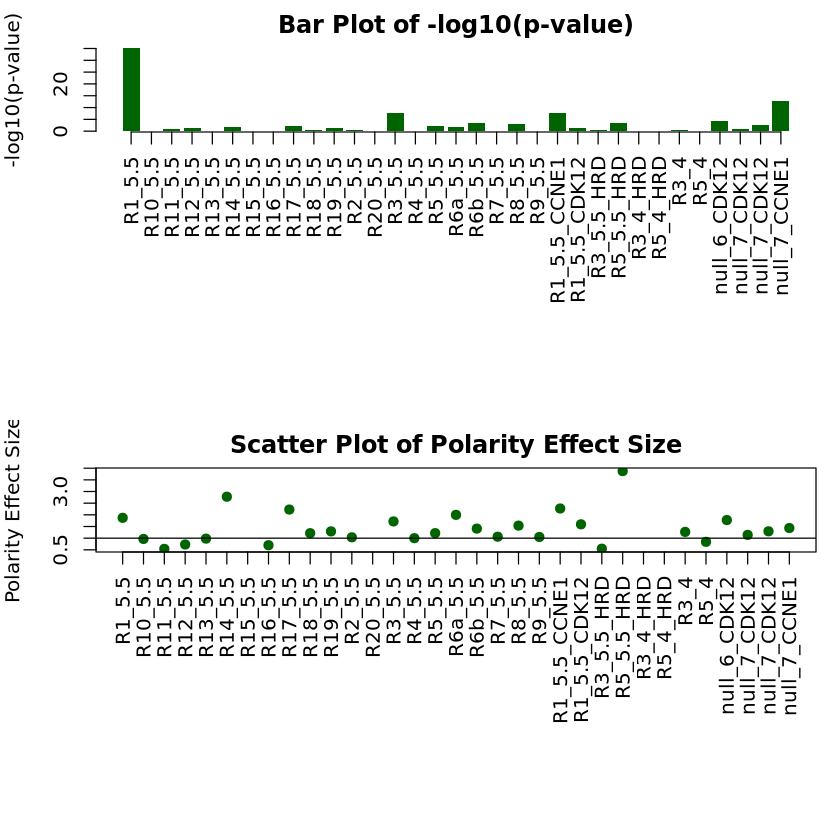

In [7]:
red <- rgb(219,0,24, maxColorValue = 255)
green <- rgb(64, 163,57, maxColorValue = 255)
blue <- rgb(44,105, 168, maxColorValue = 255)
lbs <- gsub('Ref.Sig.', '',channels_df$exp.label.short)
cols <- 'darkgreen'

# Set layout for two plots stacked in rows
par(mfrow = c(2, 1), mar = c(12, 4, 2, 1))

# First plot: Barplot of -log10(p-value)
bp <- barplot(-log10(channels_df$polarity.pval), 
              ylab = "-log10(p-value)", main = "Bar Plot of -log10(p-value)", col=cols, border=NA)
axis(1, at = bp, labels = lbs, las = 2 )
par(mar = c(12, 4, 2, 1))


# Second plot: Scatter plot of polarity effect size
plot(bp, channels_df$polarity.effsize, pch = 19,
     ylab = "Polarity Effect Size", main = "Scatter Plot of Polarity Effect Size", xlab='', xaxt = "n", col=cols)
# Add custom x-axis labels
axis(1, at = bp, labels = lbs, las = 2 )
abline(h=1)




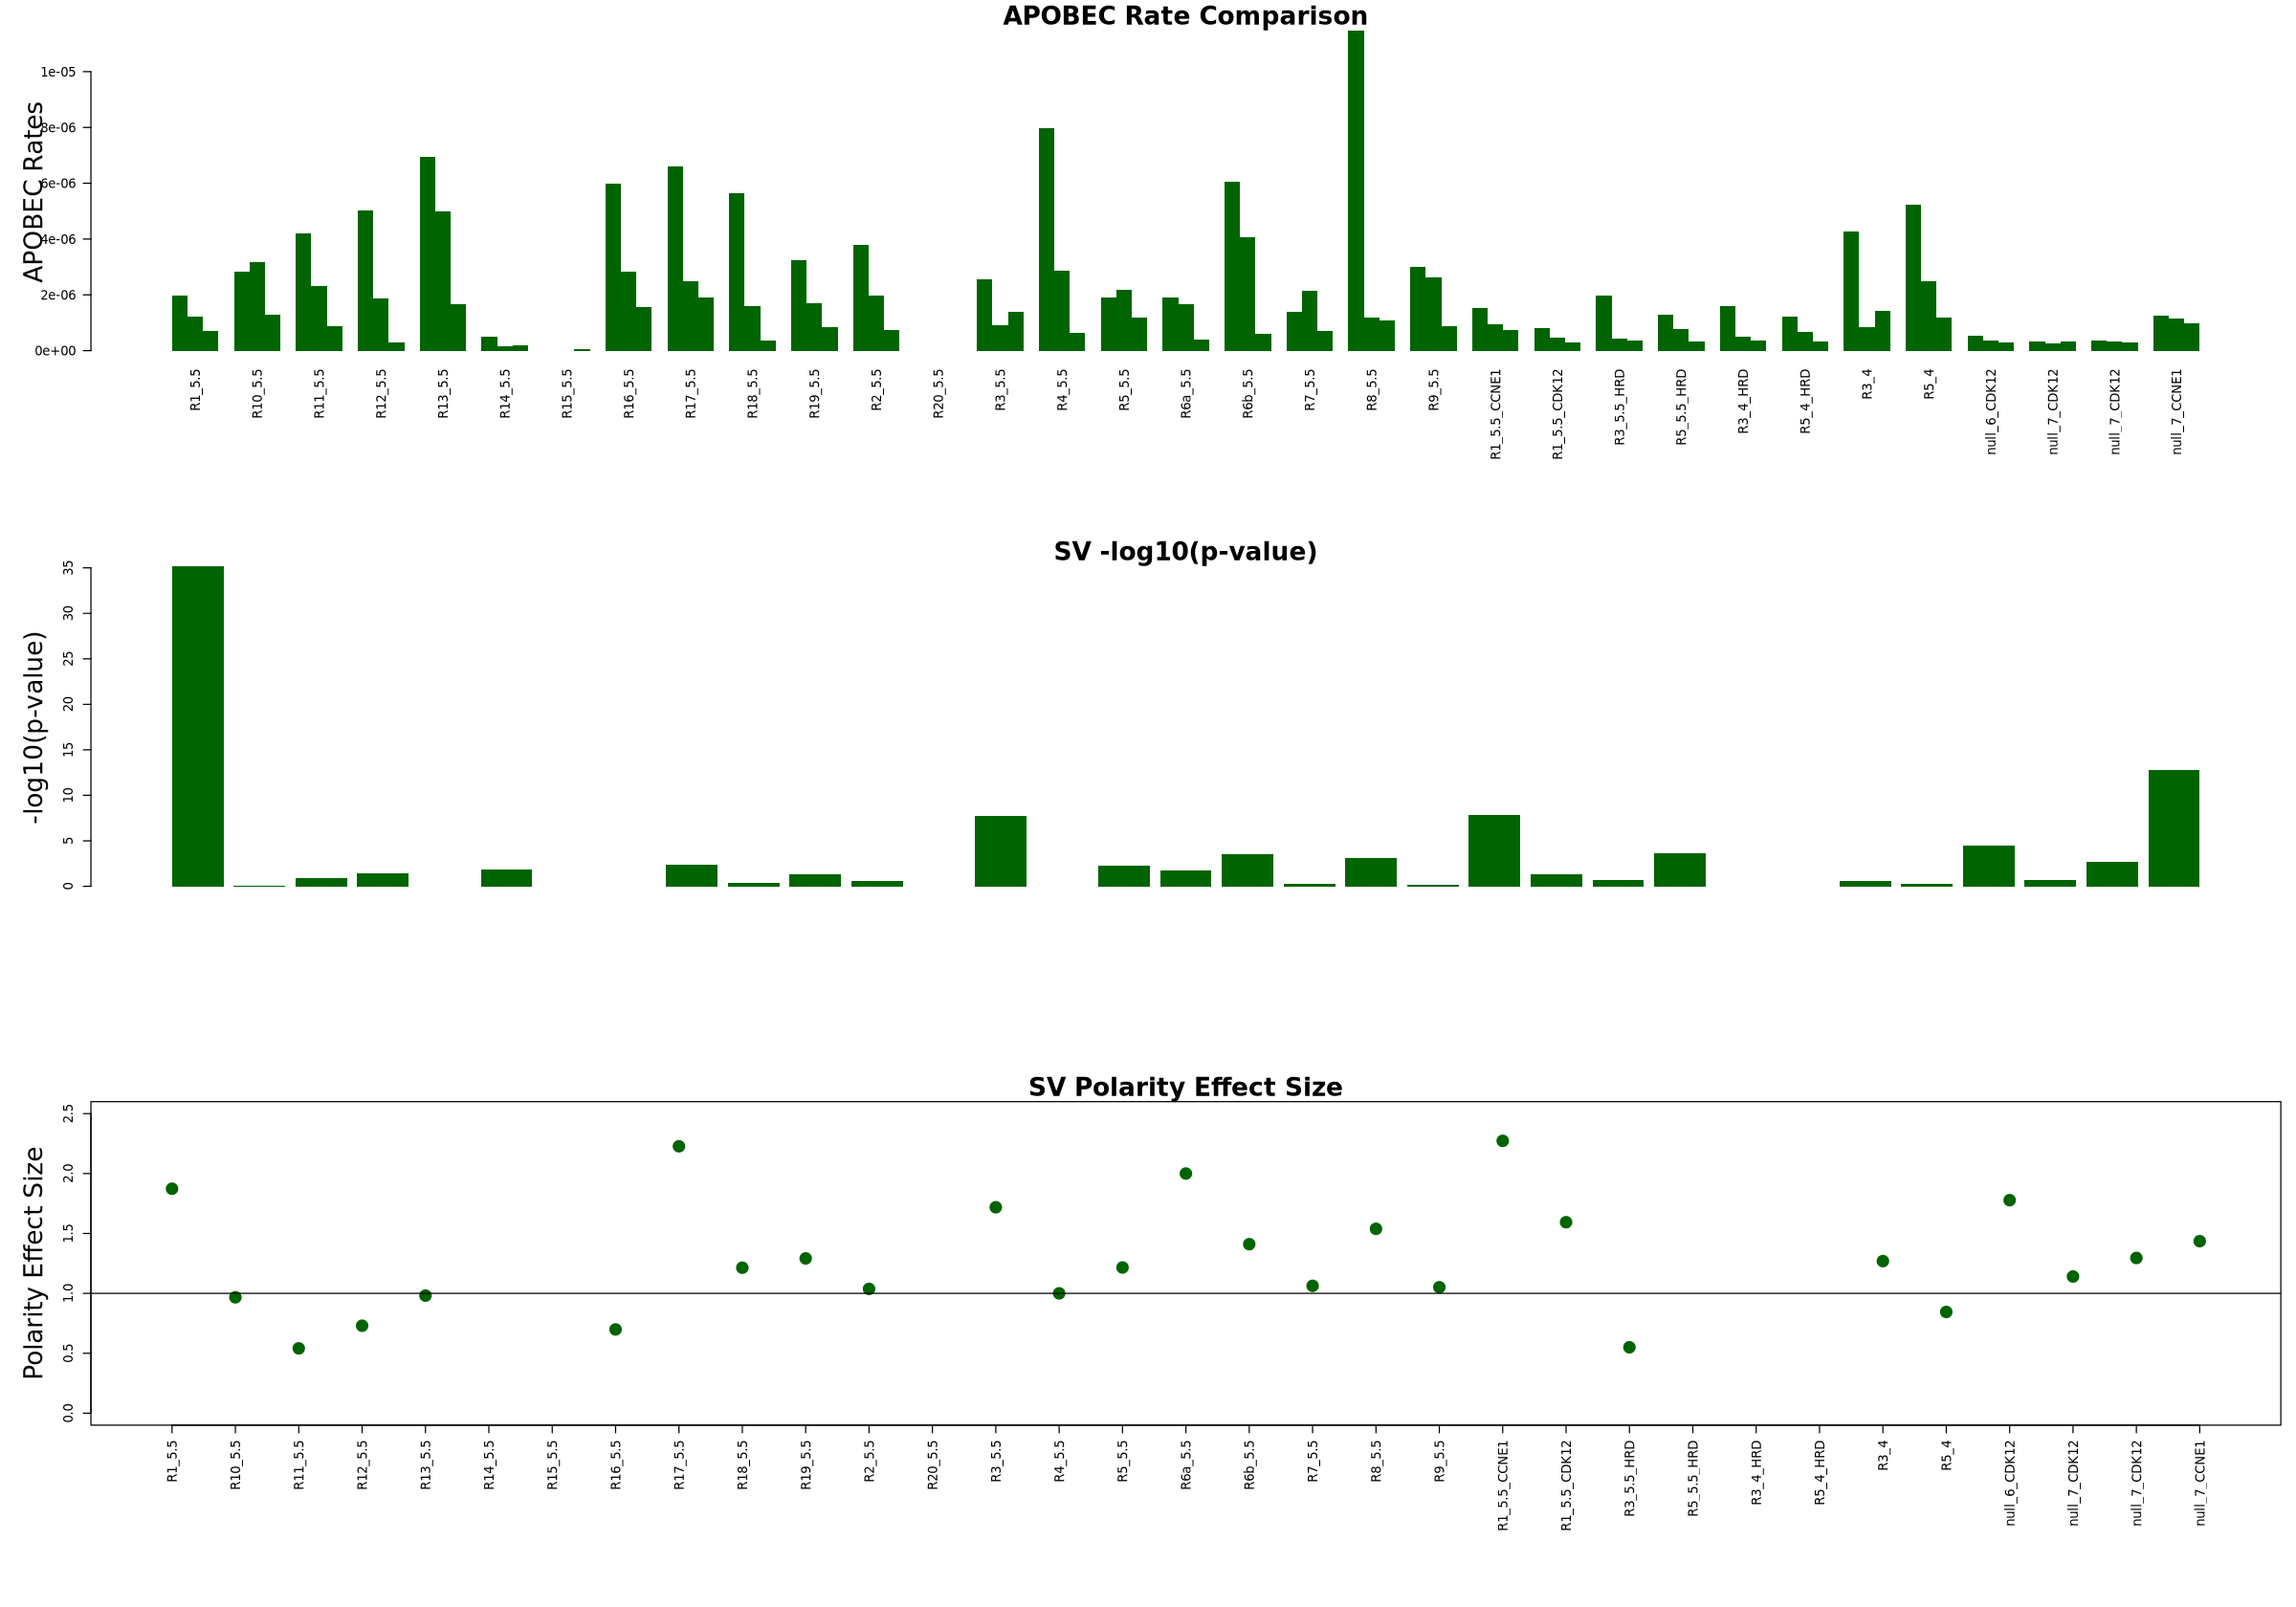

In [8]:
# Define labels
lbs <- channels_df$exp.label.short

options(repr.plot.width=20, repr.plot.height=14)

# Set layout for three plots stacked in rows
par(mfrow = c(3, 1), mar = c(12, 6, 2, 1), cex.lab = 2, cex.main = 2)

# Adjust margins for the third plot
par(mar = c(12, 6, 2, 1))

# Third plot: Barplot with three bars per category
values_matrix <- t(as.matrix(channels_df[, c('apobec.rate.sv', 'apobec.rate.margin', 'apobec.rate.bg')]))

# Create grouped bar plot

    cols_rates <- 'darkgreen'

barplot(values_matrix, beside = TRUE, col = cols_rates, 
        ylab = "APOBEC Rates", main = "APOBEC Rate Comparison", names.arg = lbs, las = 2, border = NA)


# Adjust margin for the scatter plot
par(mar = c(12, 6, 2, 1))

# First plot: Barplot of -log10(p-value)
bp <- barplot(-log10(channels_df$polarity.pval), 
              ylab = "-log10(p-value)", main = "SV -log10(p-value)", col = cols, border = NA)




# Second plot: Scatter plot of polarity effect size
plot(bp, channels_df$polarity.effsize, pch = 19,
     ylab = "Polarity Effect Size", main = "SV Polarity Effect Size", xlab = '', xaxt = "n", col = cols, cex=2, ylim=c(0,2.5))

# Add custom x-axis labels
axis(1, at = bp, labels = lbs, las = 2)
abline(h = 1)





In [9]:
colnames(values_matrix) <- lbs
values_matrix

,R1_5.5,R10_5.5,R11_5.5,R12_5.5,R13_5.5,R14_5.5,R15_5.5,R16_5.5,R17_5.5,R18_5.5,R19_5.5,R2_5.5,R20_5.5,R3_5.5,R4_5.5,R5_5.5,R6a_5.5,R6b_5.5,R7_5.5,R8_5.5,R9_5.5,R1_5.5_CCNE1,R1_5.5_CDK12,R3_5.5_HRD,R5_5.5_HRD,R3_4_HRD,R5_4_HRD,R3_4,R5_4,null_6_CDK12,null_7_CDK12,null_7_CDK12,null_7_CCNE1
apobec.rate.sv,1.987873e-06,2.832584e-06,4.195880e-06,5.019161e-06,6.953778e-06,5.089145e-07,0.000000e+00,5.970137e-06,6.595332e-06,5.631708e-06,3.233976e-06,3.798632e-06,NA,2.565872e-06,7.965536e-06,1.897534e-06,1.907721e-06,6.050178e-06,1.381260e-06,1.148249e-05,3.003113e-06,1.520163e-06,7.916770e-07,1.982708e-06,1.290807e-06,1.600118e-06,1.204377e-06,4.287970e-06,5.239988e-06,5.319594e-07,3.188699e-07,3.618245e-07,1.266560e-06
apobec.rate.margin,1.203599e-06,3.158021e-06,2.311436e-06,1.866517e-06,4.974619e-06,1.409978e-07,0.000000e+00,2.815534e-06,2.477432e-06,1.595059e-06,1.693735e-06,1.961711e-06,NA,9.159458e-07,2.858967e-06,2.188062e-06,1.666667e-06,4.073383e-06,2.140517e-06,1.168845e-06,2.634905e-06,9.535582e-07,4.785754e-07,4.452467e-07,7.745505e-07,5.020921e-07,6.666667e-07,8.509500e-07,2.491376e-06,3.532156e-07,2.483372e-07,3.204694e-07,1.160575e-06
apobec.rate.bg,7.138514e-07,1.301893e-06,8.791971e-07,2.797824e-07,1.679973e-06,2.018946e-07,5.730745e-08,1.548205e-06,1.909188e-06,3.591122e-07,8.426300e-07,7.294239e-07,NA,1.387259e-06,6.399865e-07,1.188753e-06,3.850029e-07,5.877340e-07,7.133726e-07,1.094891e-06,8.703007e-07,7.365739e-07,3.061497e-07,3.543200e-07,3.286301e-07,3.553123e-07,3.305493e-07,1.438886e-06,1.197980e-06,3.043363e-07,3.111639e-07,3.054774e-07,9.918943e-07


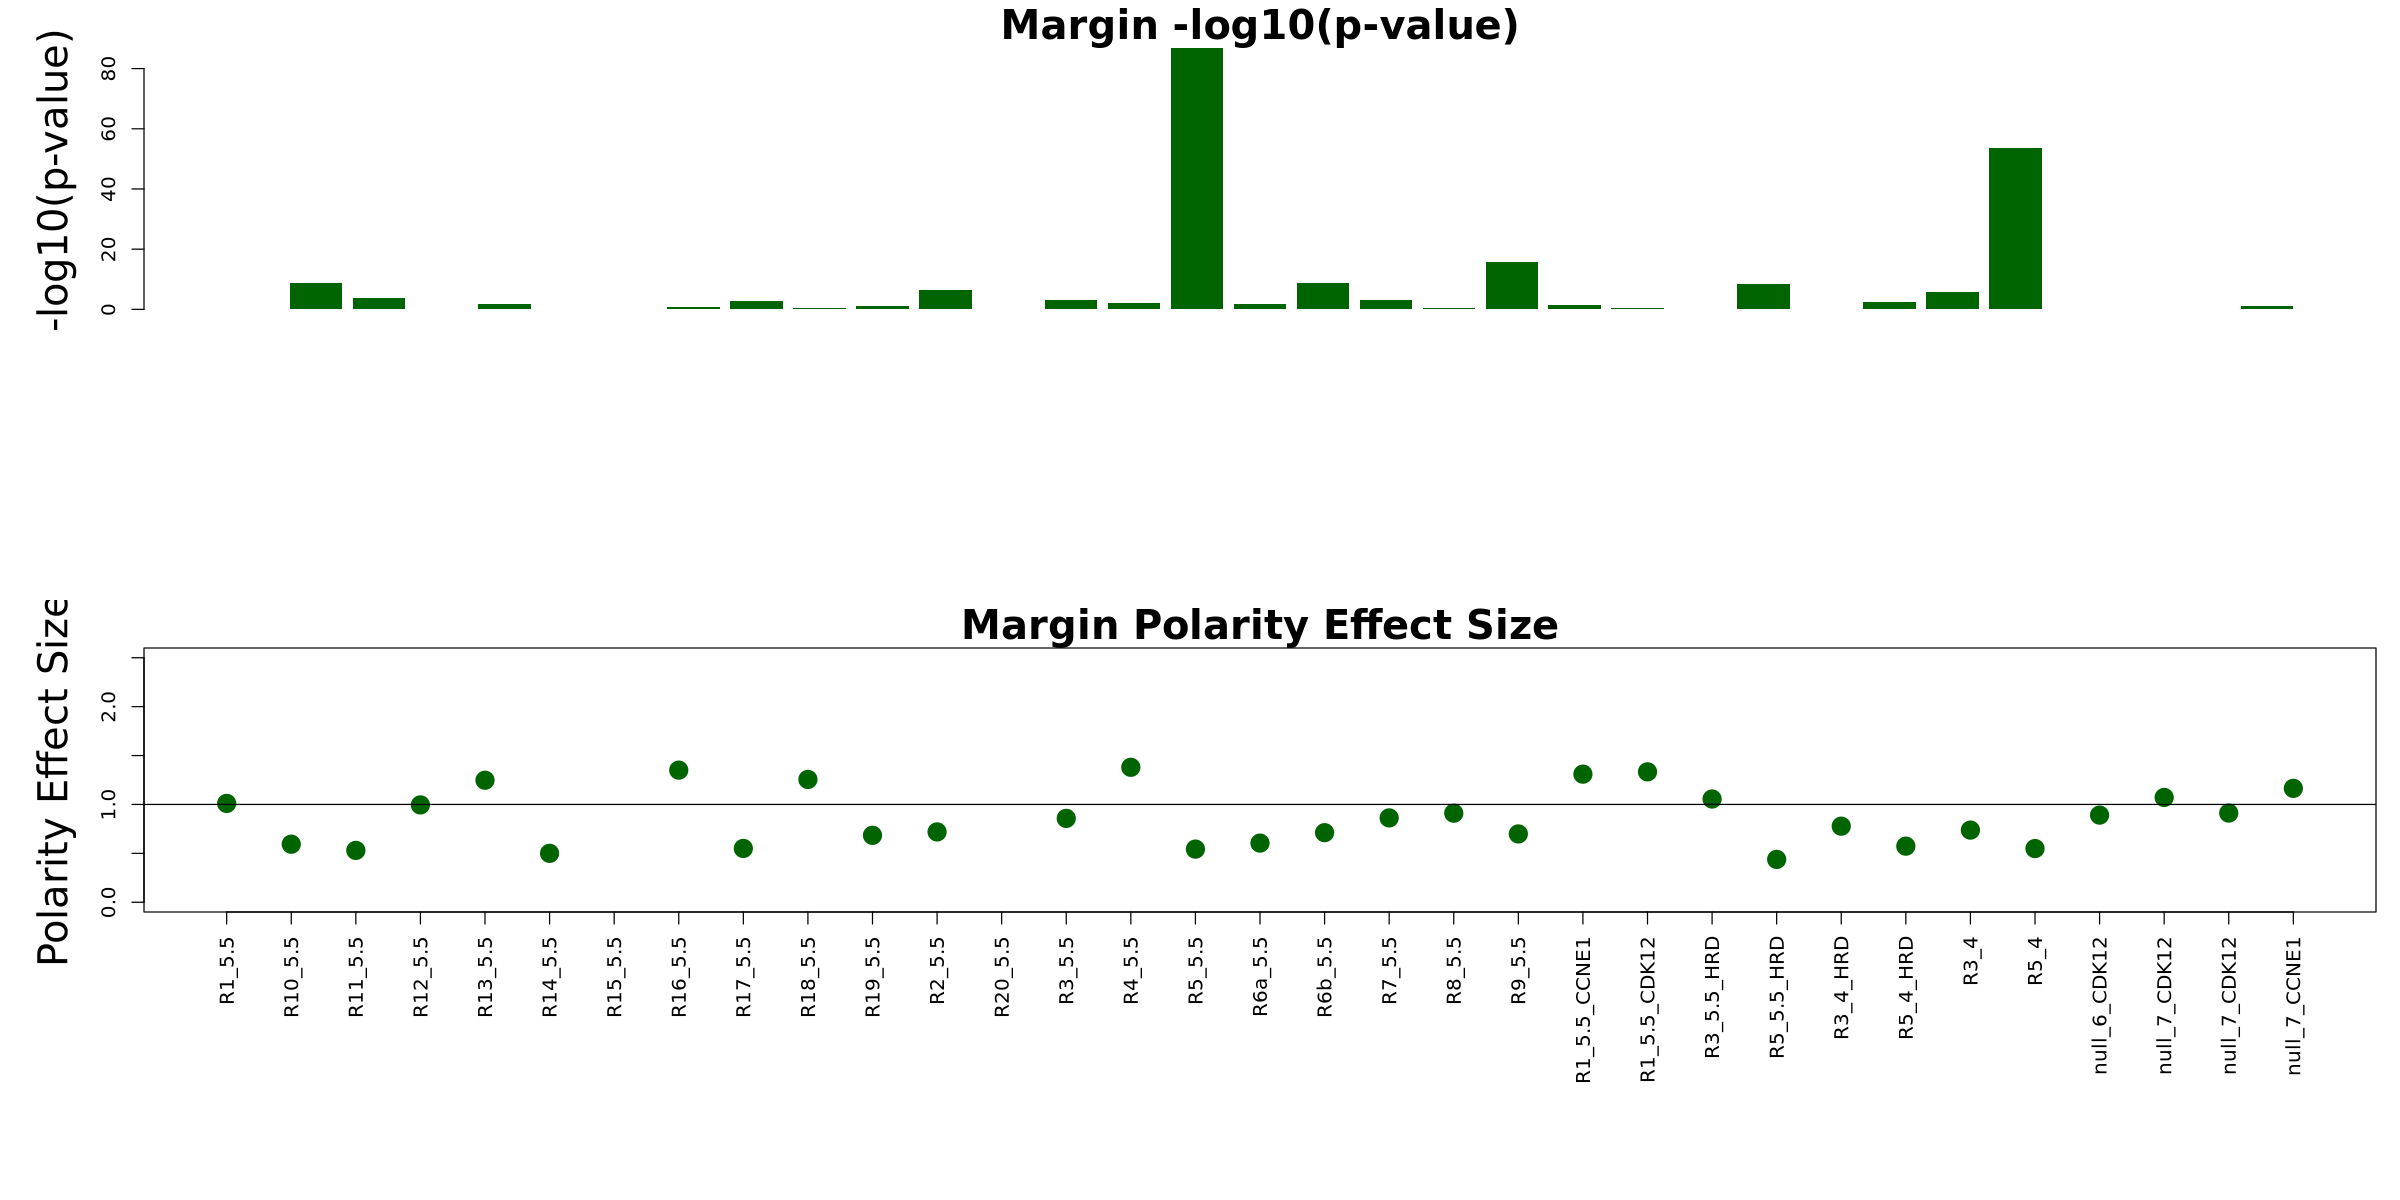

In [10]:
lbs <- gsub('Ref.Sig.', '',channels_df$exp.label.short)

options(repr.plot.width=20, repr.plot.height=10)

# Set layout for three plots stacked in rows
par(mfrow = c(2, 1), mar = c(4, 6, 2, 1), cex.lab = 2, cex.main = 2)

# Adjust margin for the scatter plot
par(mar = c(12, 6, 2, 1))

# First plot: Barplot of -log10(p-value)
bp <- barplot(-log10(channels_df$polarity.margin.pval	), 
              ylab = "-log10(p-value)", main = "Margin -log10(p-value)", col = cols, border = NA)




# Second plot: Scatter plot of polarity effect size
plot(bp, channels_df$polarity.margin.effsize, pch = 19,
     ylab = "Polarity Effect Size", main = "Margin Polarity Effect Size", xlab = '', xaxt = "n", col = cols, cex=2, ylim=c(0,2.5))

# Add custom x-axis labels
axis(1, at = bp, labels = lbs, las = 2)
abline(h = 1)



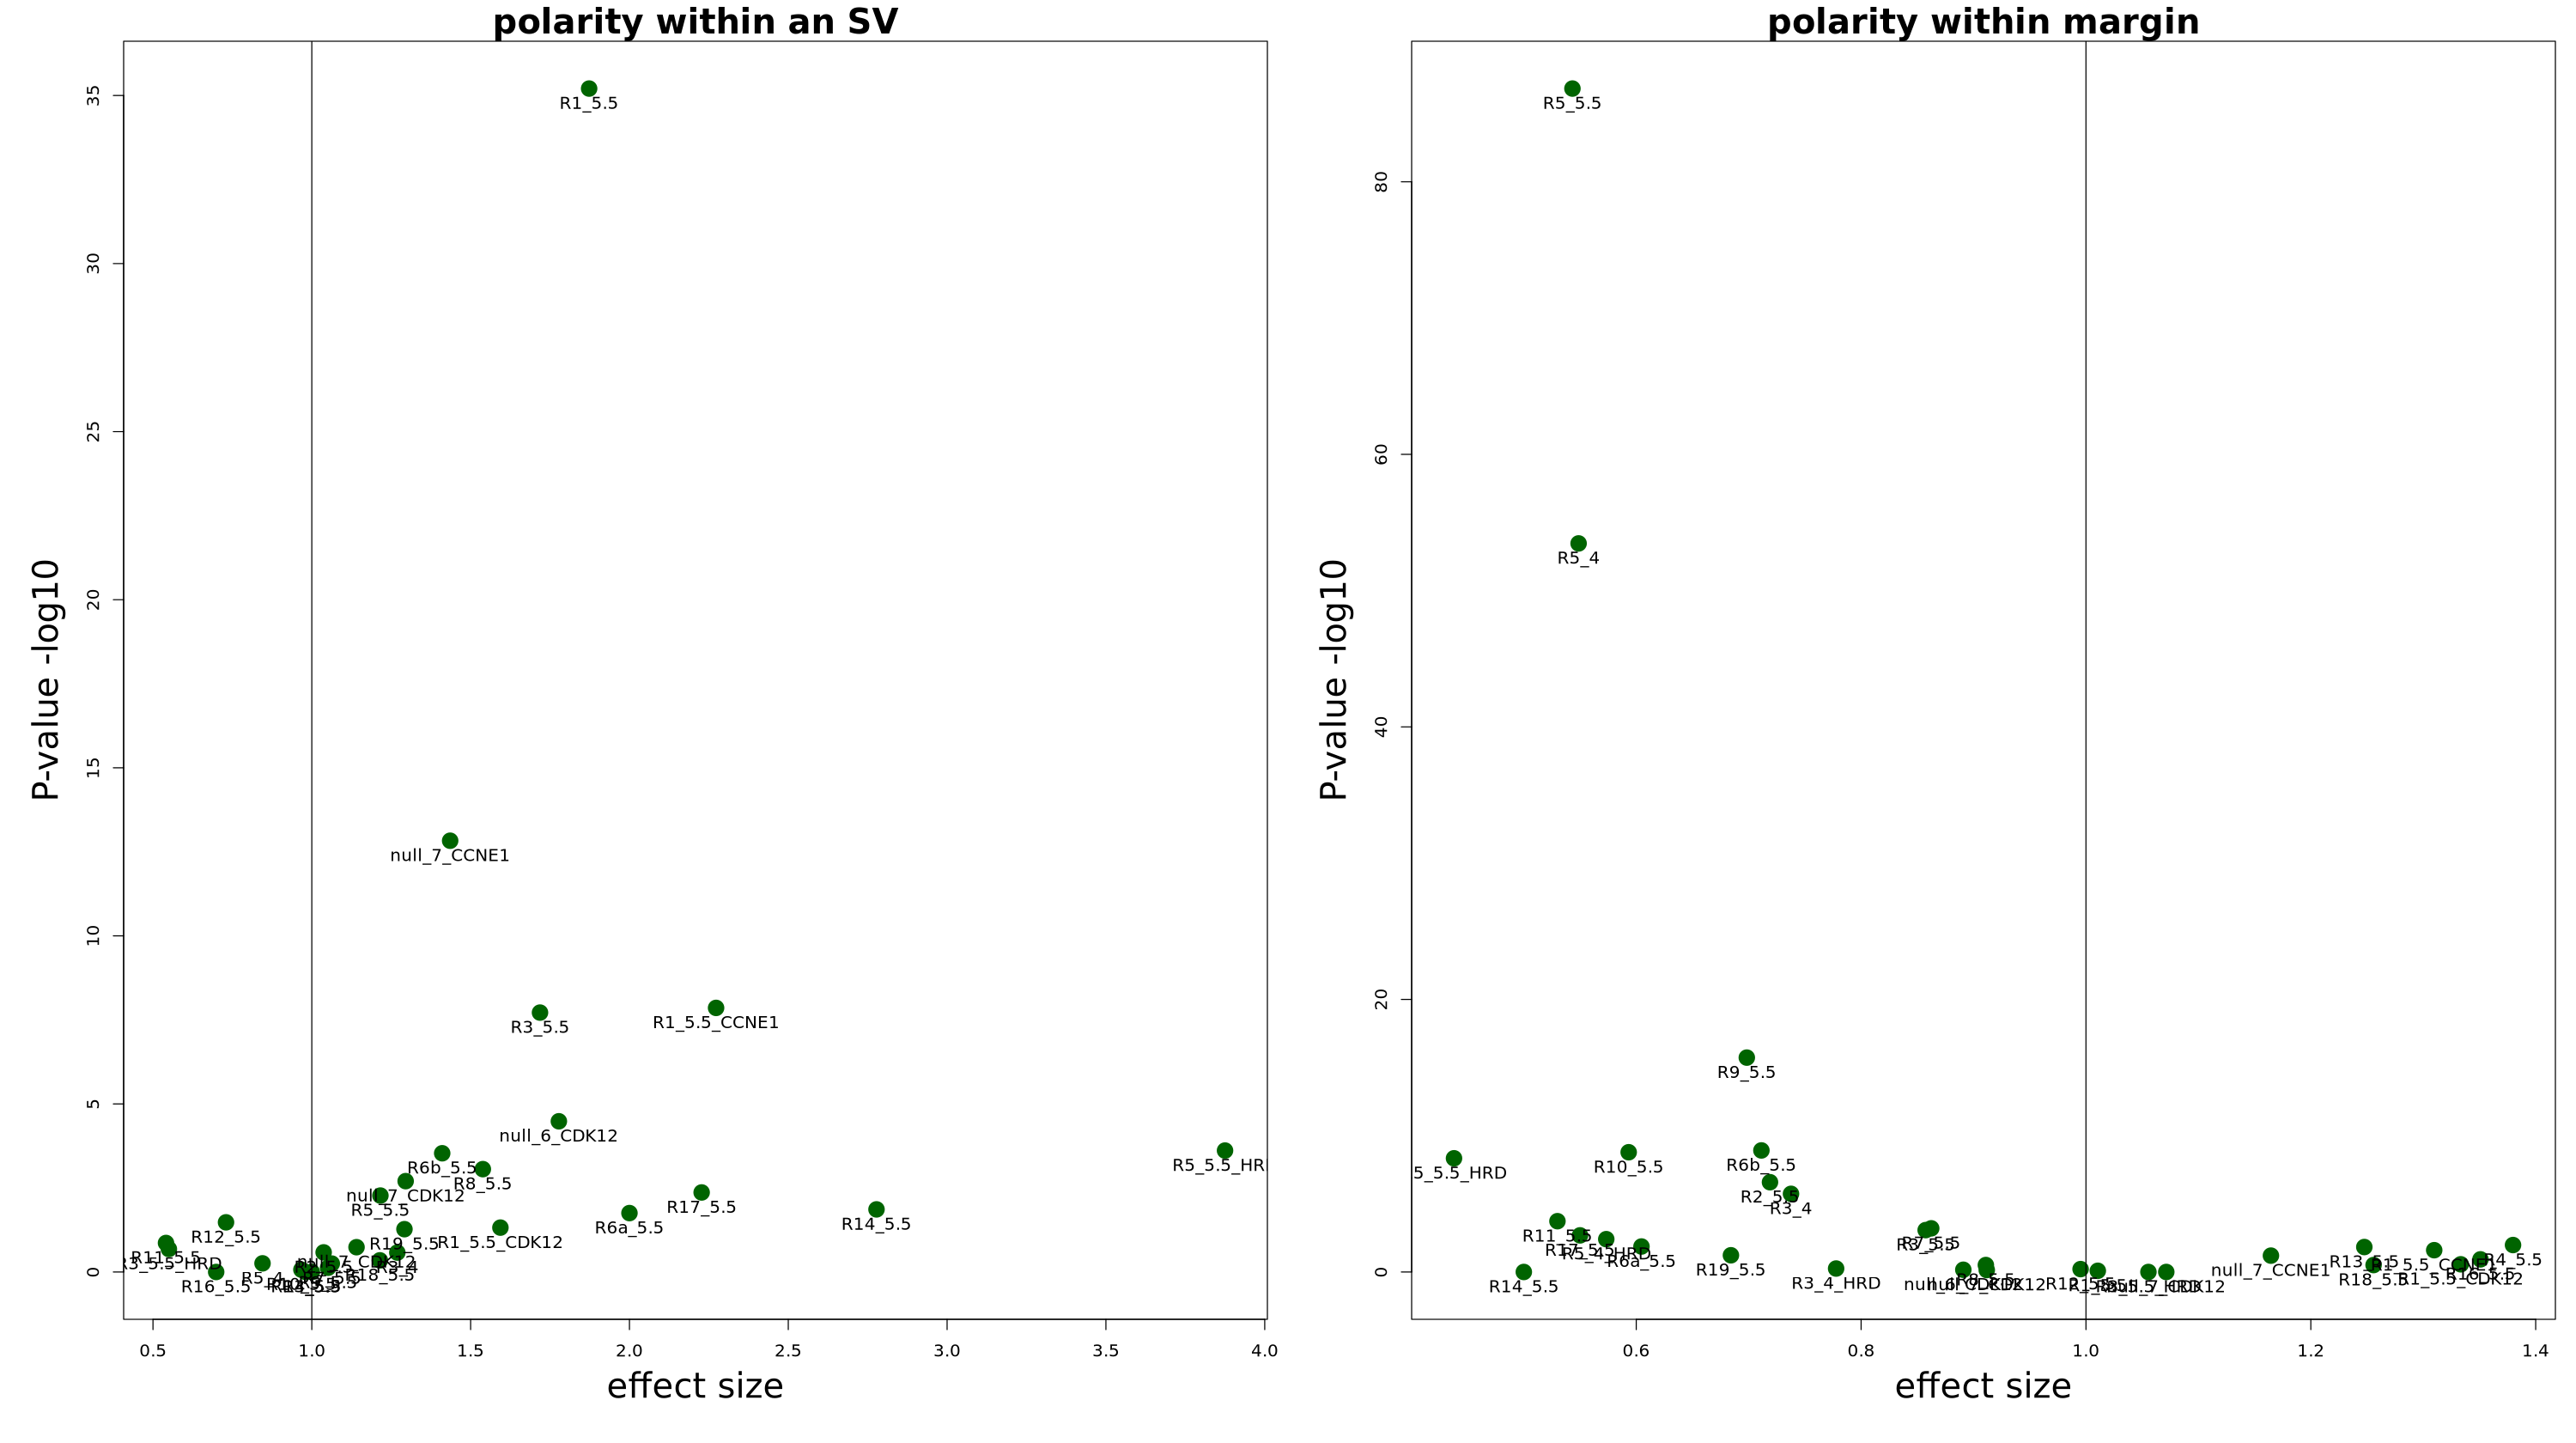

In [11]:
options(repr.plot.width=25, repr.plot.height=14)
par(mfrow = c(1, 2), mar = c(6, 6, 2, 1), cex.lab = 2, cex.main = 2)


plot(channels_df$polarity.effsize, 
     -log10(channels_df$polarity.pval), pch=19, col=cols, cex=2, main='polarity within an SV', xlab='effect size', ylab='P-value -log10')#, xlim=c(0, 2.5))
abline(v=1)
text(channels_df$polarity.effsize, 
     -log10(channels_df$polarity.pval),
     label=gsub('Ref.Sig.', '', channels_df$exp.label.short), pos=1)


plot(channels_df$polarity.margin.effsize, 
     -log10(channels_df$polarity.margin.pval), pch=19, col=cols, cex=2, main='polarity within margin', xlab='effect size', ylab='P-value -log10')#, xlim=c(0, 2.5))
abline(v=1)
text(channels_df$polarity.margin.effsize, 
     -log10(channels_df$polarity.margin.pval),
     label=gsub('Ref.Sig.', '',channels_df$exp.label.short), pos=1)


Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


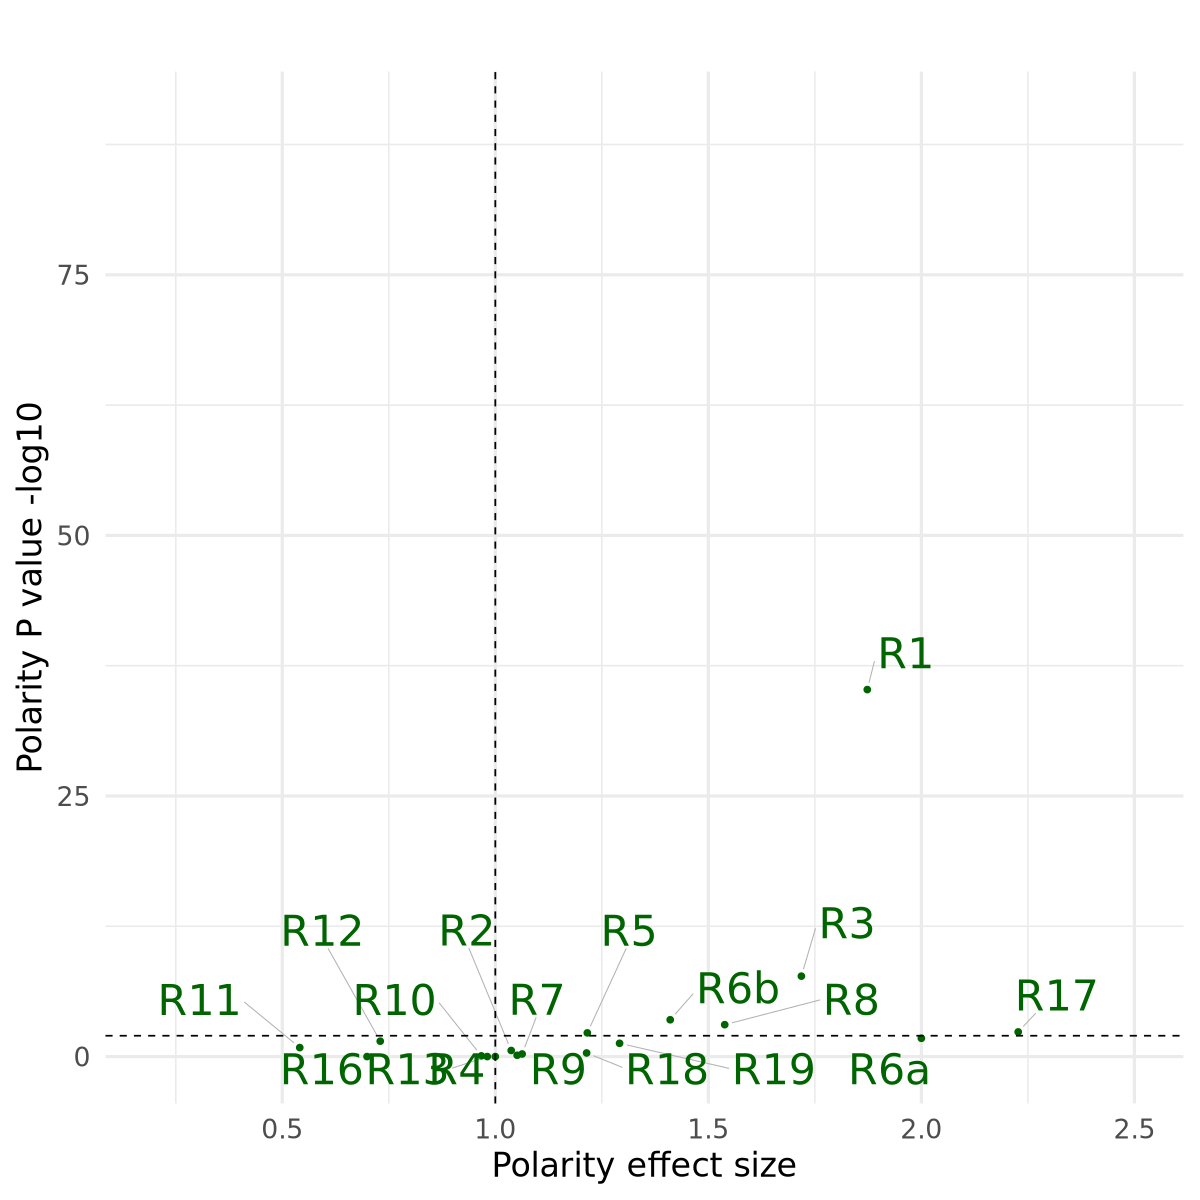

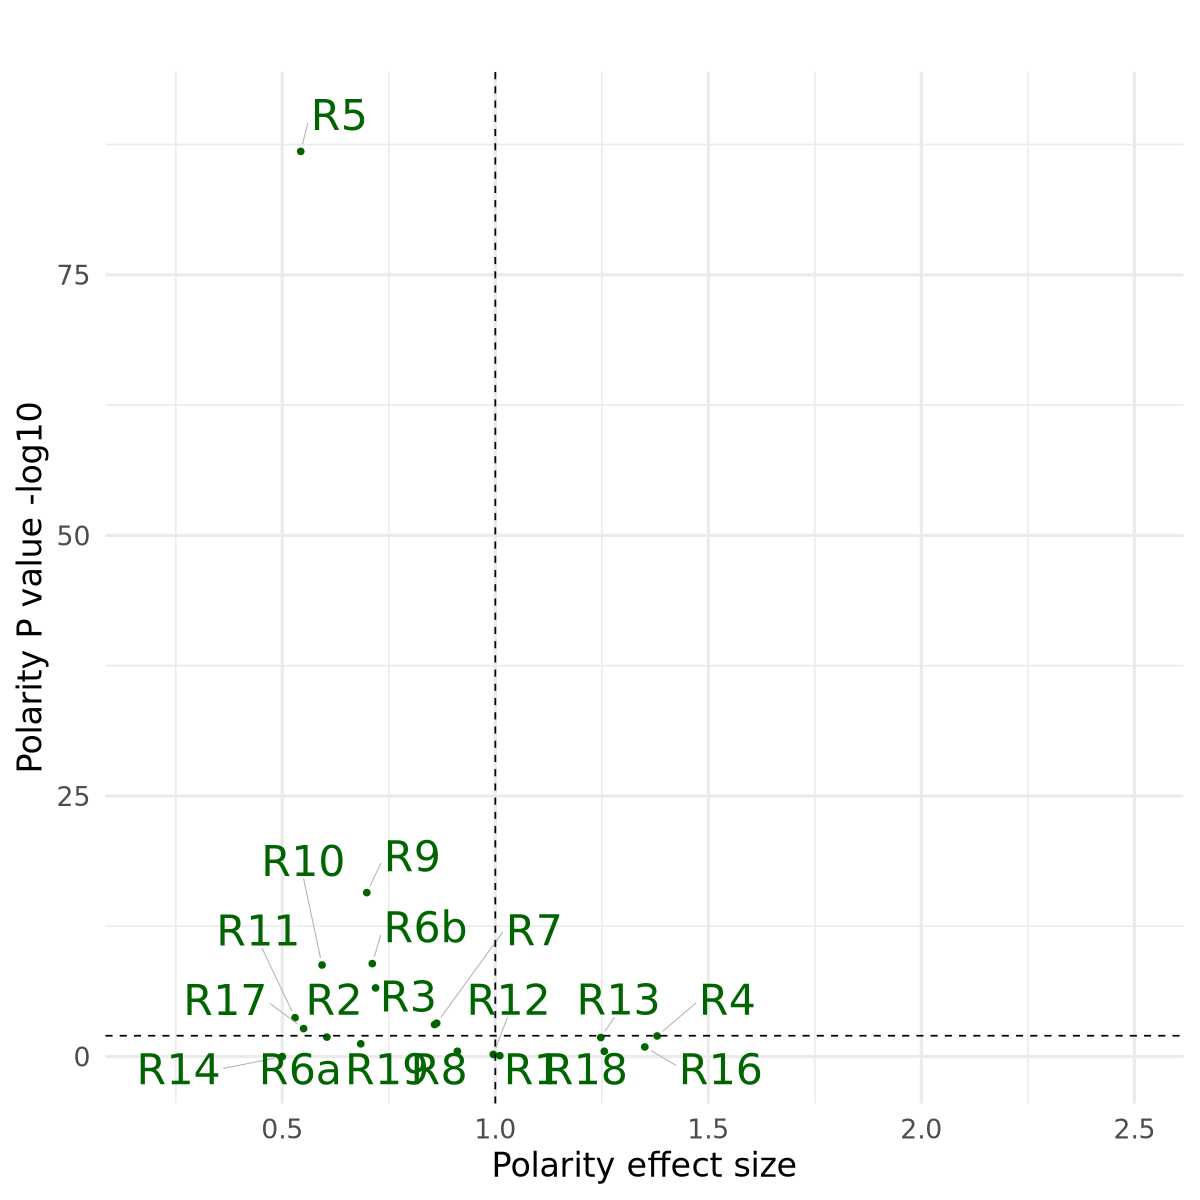

In [12]:
channels_df$polarity.pval.mlog10 = -log10(channels_df$polarity.pval)
channels_df$polarity.margin.pval.mlog10 = -log10(channels_df$polarity.margin.pval)

channels_df_sel <- subset(channels_df, max_size==3e+05 & sample_subset=='')
channels_df_sel$exp.label.short.plot <-  gsub('_.*','',gsub('Ref.Sig.', '', channels_df_sel$exp.label.short))

if (makePdfs) {
    pdf("~/projects/rsignatures/data/processed/svig_paper/APOBEC_SVs.pdf", width = 10, height = 10)  # Open PDF device
} else {
    options(repr.plot.width=10, repr.plot.height=10)
}

ggplot(channels_df_sel, aes(x = polarity.effsize, y = polarity.pval.mlog10, label = exp.label.short.plot)) +
  geom_point(color = "darkgreen") +
  geom_text_repel(
    color = "darkgreen",
    angle = 0,
    size = 9,
    max.overlaps = 1000,
    box.padding = 0.8,
    point.padding = 0.5,
    segment.color = "grey70",
    segment.size = 0.3
  ) +
  geom_hline(yintercept = 2, linetype = "dashed") +
  geom_vline(xintercept = 1, linetype = "dashed") +
  xlab("Polarity effect size") +
  ylab("Polarity P value -log10") +
  ggtitle("") +
  theme_minimal(base_size = 20) +
  xlim(0.2, 2.5) +
  ylim(0, 90) +
  theme(legend.position = "none")
if (makePdfs) {
    dev.off()  # Close PDF device
}

if (makePdfs) {
    pdf("~/projects/rsignatures/data/processed/svig_paper/APOBEC_margins.pdf", width = 10, height = 10)  # Open PDF device
} else {
    options(repr.plot.width=10, repr.plot.height=10)
}
ggplot(channels_df_sel, aes(x = polarity.margin.effsize, y = polarity.margin.pval.mlog10, label = exp.label.short.plot)) +
  geom_point(color = "darkgreen") +
  geom_text_repel(
    color = "darkgreen",
    angle = 0,
    size = 9,
    max.overlaps = 1000,
    box.padding = 0.8,
    point.padding = 0.5,
    segment.color = "grey70",
    segment.size = 0.3
  ) +
  geom_hline(yintercept = 2, linetype = "dashed") +
  geom_vline(xintercept = 1, linetype = "dashed") +
  xlab("Polarity effect size") +
  ylab("Polarity P value -log10") +
  ggtitle("") +
  theme_minimal(base_size = 20) +
  xlim(0.2, 2.5) +
  ylim(0, 90) +
  theme(legend.position = "none")
if (makePdfs) {
    dev.off()  # Close PDF device
}

Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


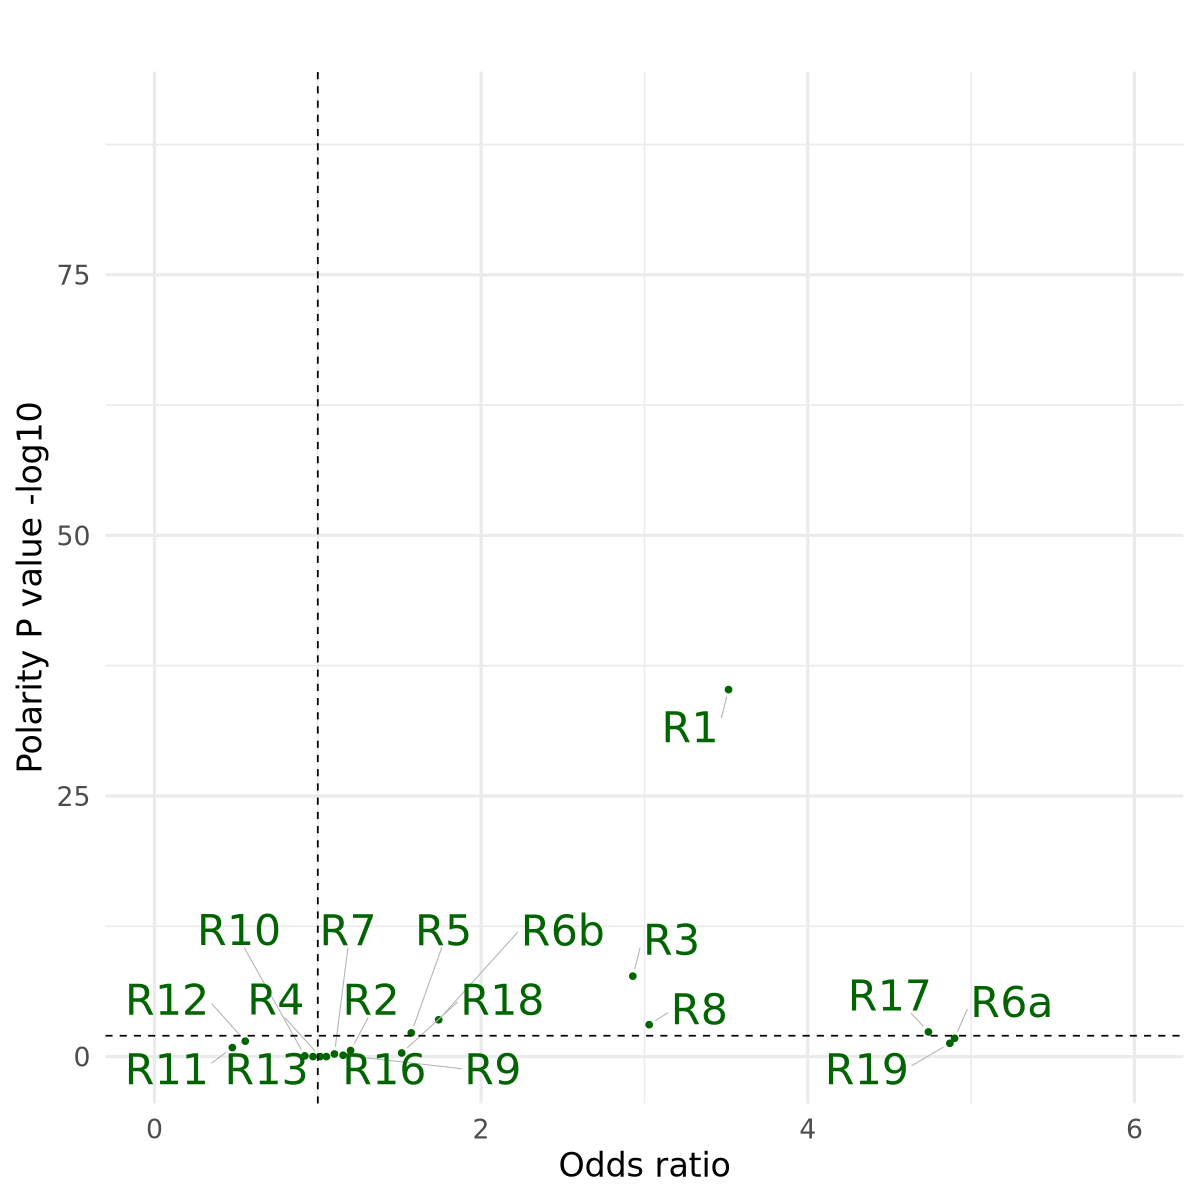

In [13]:
if (makePdfs) {
    pdf("~/projects/rsignatures/data/processed/svig_paper/APOBEC_SVs_odds.pdf", width = 10, height = 10)  # Open PDF device
} else {
    options(repr.plot.width=10, repr.plot.height=10)
}

ggplot(channels_df_sel, aes(x = odds.ratio.sv, y = polarity.pval.mlog10, label = exp.label.short.plot)) +
  geom_point(color = "darkgreen") +
  geom_text_repel(
    color = "darkgreen",
    angle = 0,
    size = 9,
    max.overlaps = 1000,
    box.padding = 0.8,
    point.padding = 0.5,
    segment.color = "grey70",
    segment.size = 0.3
  ) +
  geom_hline(yintercept = 2, linetype = "dashed") +
  geom_vline(xintercept = 1, linetype = "dashed") +
  xlab("Odds ratio") +
  ylab("Polarity P value -log10") +
  ggtitle("") +
  theme_minimal(base_size = 20) +
  xlim(0, 6) +
  ylim(0, 90) +
  theme(legend.position = "none")
if (makePdfs) {
    dev.off()  # Close PDF device
}

pdf("~/projects/rsignatures/data/processed/svig_paper/APOBEC_margins_odds.pdf", width = 10, height = 10)  # Open PDF device

ggplot(channels_df_sel, aes(x = odds.ratio.margin, y = polarity.margin.pval.mlog10, label = exp.label.short.plot)) +
  geom_point(color = "darkgreen") +
  geom_text_repel(
    color = "darkgreen",
    angle = 0,
    size = 9,
    max.overlaps = 1000,
    box.padding = 0.8,
    point.padding = 0.5,
    segment.color = "grey70",
    segment.size = 0.3
  ) +
  geom_hline(yintercept = 2, linetype = "dashed") +
  geom_vline(xintercept = 1, linetype = "dashed") +
  xlab("Odds ratio") +
  ylab("Fisher P value -log10") +
  ggtitle("") +
  theme_minimal(base_size = 20) +
  xlim(0, 6) +
  ylim(0, 90) +
  theme(legend.position = "none")

if (makePdfs) {
    dev.off()  # Close PDF device
}    

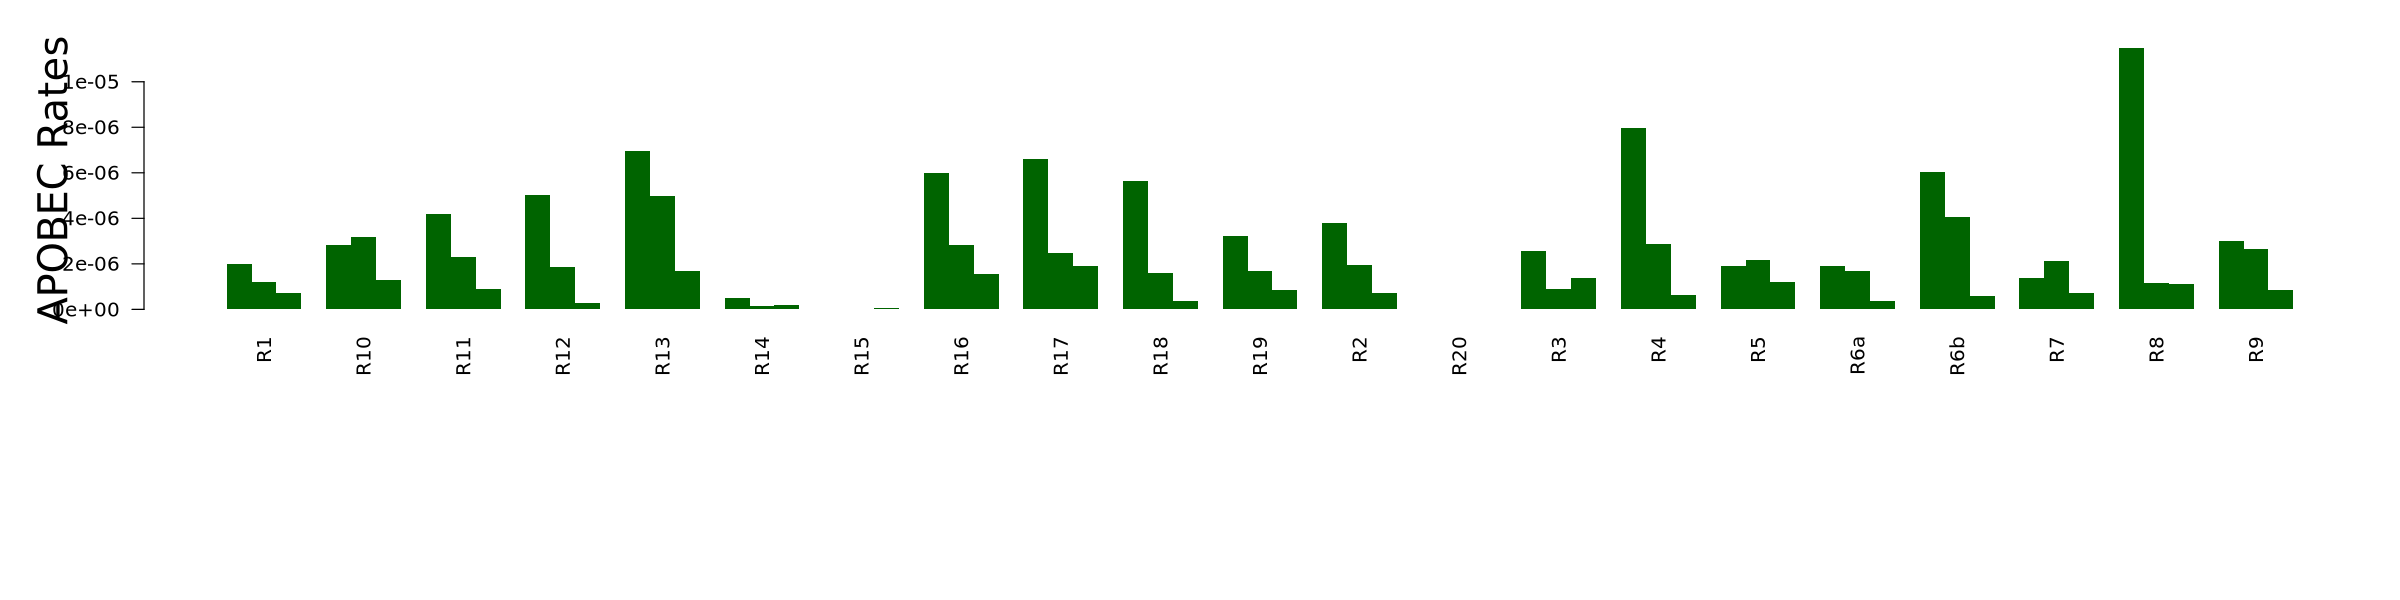

In [14]:
channels_df_sel2 <- subset(channels_df_sel, TRUE)
#channels_df_sel2 <- subset(channels_df_sel, exp.label %in% c('Ref.Sig.R1', 'Ref.Sig.R3', 'Ref.Sig.R5', 'Ref.Sig.R7', 'Ref.Sig.R8'))
channels_df_sel2$exp.label.short.plot <-  gsub('_.*','',gsub('Ref.Sig.', '', channels_df_sel2$exp.label.short))

    
lbs <- channels_df_sel2$exp.label.short.plot

options(repr.plot.width=20, repr.plot.height=5)

# Set layout for three plots stacked in rows
par( mar = c(12, 6, 2, 1), cex.lab = 2, cex.main = 2)

# Adjust margins for the third plot
par(mar = c(12, 6, 2, 1))

# Third plot: Barplot with three bars per category
values_matrix <- t(as.matrix(channels_df_sel2[, c('apobec.rate.sv', 'apobec.rate.margin', 'apobec.rate.bg')]))

# Create grouped bar plot
cols_rates <- 'darkgreen'

barplot(values_matrix, beside = TRUE, col = cols_rates, 
        ylab = "APOBEC Rates", main = "", names.arg = lbs, las = 2, border = NA)

In [15]:
write.csv(channels_df, file='../data/processed/APOBEC_sig_channels_df.csv')